# User Trust Calibration & Data Analysis

## Overview
In this notebook, we analyse the **user responses** (`user_responses.csv`) collected from participants (whose demographics and background are recorded in `user_metadata.csv`) for the questions presented alongside LLM-generated outputs in the **model outputs dataset** (`model_outputs_all_datasets.csv`).

For correctness analysis, we use **LLM-as-judge evaluations** from `model_outputs_all_datasets_GPT4mini_Claude_Judged.csv`, which contains judgements from both GPT-4 mini and Claude models, with human validation applied to disagreement cases.

## Objectives
1. **Trust Calibration** – Assess and calibrate user trust in LLM-generated explanations across different datasets and model configurations.
2. **Correctness Analysis** – Evaluate whether user trust aligns with actual answer correctness (determined via LLM judgements with human validation).
3. **Exploratory Data Analysis** – Investigate patterns, distributions, and relationships within the collected responses to surface meaningful insights.
4. **Emergent Findings** – Discover any additional trends, correlations, or anomalies worth reporting.

In [53]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import spearmanr
import seaborn as sns
from scipy.stats import pearsonr
from scipy.stats import kruskal
from collections import Counter
import re
from scipy.stats import friedmanchisquare, wilcoxon
from itertools import combinations

In [54]:
plt.close("all")

## Figure Export Automation
This setup cell patches `matplotlib` so every `plt.show()` both displays and saves each open figure to the `images` folder.

- Saves `PNG` files at **300 DPI** for high-resolution raster output.
- Saves `PDF` files for vector-quality publication graphics.
- Uses auto-generated, ordered filenames based on figure titles.

Run this once after imports, then run the rest of the notebook normally.

In [ ]:
from pathlib import Path
import re

# Auto-save every displayed matplotlib figure for paper-ready use.
IMAGES_DIR = Path("images")
IMAGES_DIR.mkdir(parents=True, exist_ok=True)
SAVE_DPI = 300
SAVE_FORMATS = ("png", "pdf")

# Prevent double-wrapping if cell is re-run
if not hasattr(plt, '_original_show_unwrapped'):
    plt._original_show_unwrapped = plt.show

_ORIGINAL_SHOW = plt._original_show_unwrapped
_saved_figures = 0


def _slugify(text: str) -> str:
    text = (text or "figure").strip().lower()
    text = re.sub(r"[^a-z0-9]+", "_", text)
    return text.strip("_") or "figure"


def _figure_title(fig) -> str:
    if getattr(fig, "_suptitle", None) is not None:
        return fig._suptitle.get_text()
    for ax in fig.axes:
        title = ax.get_title()
        if title:
            return title
    return "figure"


def save_and_show(*args, **kwargs):
    global _saved_figures
    for fig_num in plt.get_fignums():
        fig = plt.figure(fig_num)
        _saved_figures += 1
        stem = f"{_saved_figures:03d}_{_slugify(_figure_title(fig))}"

        for fmt in SAVE_FORMATS:
            output_path = IMAGES_DIR / f"{stem}.{fmt}"
            save_kwargs = {"bbox_inches": "tight", "format": fmt}
            if fmt == "png":
                save_kwargs["dpi"] = SAVE_DPI
            fig.savefig(output_path, **save_kwargs)
            print(f"Saved figure: {output_path}")

    _ORIGINAL_SHOW(*args, **kwargs)
    plt.close("all")


plt.show = save_and_show
print(
    f"Auto-save enabled. Figures will be saved to '{IMAGES_DIR}' as {', '.join(SAVE_FORMATS)} "
    f"(PNG at {SAVE_DPI} DPI, PDF vector format)."
)

Auto-save enabled. Figures will be saved to 'images' as png, pdf (PNG at 300 DPI, PDF vector format).


## Load Data & Convert Numeric Columns
Load the user responses dataset and ensure that scored columns (`trust_score`, `helpfulness_score`, `confidence_alignment`) are cast to proper numeric types, coercing any non-numeric entries to `NaN`.

In [56]:
# Load data
df = pd.read_csv("user_responses.csv")

# Convert numeric columns (important!)
numeric_cols = [
    "trust_score",
    "helpfulness_score",
    "confidence_alignment"
]

for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

# Drop rows with missing trust
df = df.dropna(subset=["trust_score"])

print("Total responses:", len(df))

Total responses: 300


## Mean Trust by Preferred Answer Type
Compute and visualise the **average trust score** grouped by participants' preferred answer type. This helps us understand whether users who favour a particular answer style (e.g., model-generated vs. human-written) tend to express systematically higher or lower trust in LLM outputs.


Mean Trust by Preferred Answer:
preferred_answer
Answer only                3.080292
Answer with explanation    3.119403
Disagree with both         0.448276
Name: trust_score, dtype: float64
Saved figure: images\001_mean_trust_by_preferred_answer_type.png
Saved figure: images\001_mean_trust_by_preferred_answer_type.pdf
Saved figure: images\002_mean_trust_by_preferred_answer_type.png
Saved figure: images\002_mean_trust_by_preferred_answer_type.pdf
Saved figure: images\003_mean_trust_by_preferred_answer_type.png
Saved figure: images\003_mean_trust_by_preferred_answer_type.pdf
Saved figure: images\004_mean_trust_by_preferred_answer_type.png
Saved figure: images\004_mean_trust_by_preferred_answer_type.pdf
Saved figure: images\005_mean_trust_by_preferred_answer_type.png
Saved figure: images\005_mean_trust_by_preferred_answer_type.pdf
Saved figure: images\006_mean_trust_by_preferred_answer_type.png
Saved figure: images\006_mean_trust_by_preferred_answer_type.pdf
Saved figure: images\007_mea

KeyboardInterrupt: 

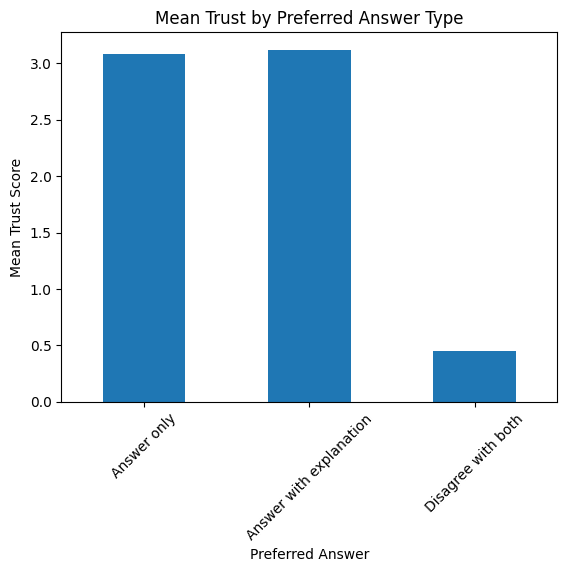

In [57]:
trust_by_pref = df.groupby("preferred_answer")["trust_score"].mean()
print("\nMean Trust by Preferred Answer:")
print(trust_by_pref)

# Bar chart
plt.figure()
trust_by_pref.plot(kind="bar")
plt.title("Mean Trust by Preferred Answer Type")
plt.ylabel("Mean Trust Score")
plt.xlabel("Preferred Answer")
plt.xticks(rotation=45)
plt.show()

## Trust by issue detection
What this tells  -  Do users reduce trust when they detect inconsistency?

In [ ]:
trust_by_issue = df.groupby("noticed_issue")["trust_score"].mean()
print("\nMean Trust by Issue Detection:")
print(trust_by_issue)

plt.figure()
trust_by_issue.plot(kind="bar")
plt.title("Mean Trust by Issue Detection")
plt.ylabel("Mean Trust Score")
plt.xlabel("Noticed Issue")
plt.xticks(rotation=0)
plt.show()

## Confidence vs Trust Correlation

Interpretation:

Close to 1 - strong positive relationship

Around 0  - no relationship

Negative  - inverse effect

In [ ]:


x = df["confidence_alignment"].values
y = df["trust_score"].values

# jitter so overlapping points become visible
xj = x + np.random.uniform(-0.12, 0.12, size=len(x))
yj = y + np.random.uniform(-0.12, 0.12, size=len(y))

plt.figure(figsize=(6,4))
plt.scatter(xj, yj, alpha=0.4, s=20)

means = df.groupby("confidence_alignment")["trust_score"].mean()
plt.plot(means.index, means.values, marker="o", color="black", linewidth=2, label="Mean trust")

plt.xticks(range(6)); plt.yticks(range(6))
plt.xlabel("Confidence Alignment")
plt.ylabel("Trust Score")
plt.title("Alignment vs Trust (jittered + mean)")
plt.legend()
plt.grid(alpha=0.2)
plt.show()

## Lets also do a per user correlation between confidence alignment and trust score, to see if the relationship holds at the individual level.

Because each participant provided multiple ratings (≈15 items), we computed within-participant Spearman correlations between confidence alignment and trust. The distribution of per-user correlations was predominantly positive (median ≈ 0.77; mean ≈ 0.64), indicating that for most participants, higher perceived alignment between model confidence and their own confidence corresponded to higher trust ratings. In contrast, the correlation between participant-level mean alignment and mean trust was weaker (≈0.33), suggesting substantial individual differences in baseline trus

In [ ]:
# Spearman per-user correlation
rows = []
skipped = []
for uid, g in df.groupby("user_id"):
    g = g[["confidence_alignment", "trust_score"]].dropna()

    # must have variation in both columns
    if g["confidence_alignment"].nunique() > 1 and g["trust_score"].nunique() > 1:
        corr = g["confidence_alignment"].corr(g["trust_score"], method="spearman")
        rows.append({
            "user_id": uid,
            "n_rows": len(g),
            "spearman_within": corr
        })
    else:
        skipped.append({
            "user_id": uid,
            "n_rows": len(g),
            "unique_conf_align": g["confidence_alignment"].nunique(),
            "unique_trust": g["trust_score"].nunique(),
            "reason": "no variation in confidence_alignment and/or trust_score"
        })

per_user = pd.DataFrame(rows).sort_values("spearman_within", ascending=False)
print(per_user)
print("\nSummary:")
print(per_user["spearman_within"].describe())

if skipped:
    print(f"\n⚠ {len(skipped)} user(s) skipped (constant values → correlation undefined):")
    print(pd.DataFrame(skipped).to_string(index=False))

## 1. Response Volume by Dataset
How many responses were collected for each dataset? This gives us a sense of balance and whether any dataset is under-represented.

In [ ]:
# Response count by dataset
print("Response count by dataset:")
print(df["dataset"].value_counts())
print(f"\nTotal responses: {len(df)}")

# Pie chart of response distribution
plt.figure(figsize=(6, 4))
df["dataset"].value_counts().plot(kind="pie", autopct="%1.1f%%", startangle=140)
plt.title("Response Distribution by Dataset")
plt.ylabel("")  # hide default ylabel
plt.tight_layout()
plt.show()

## 2. Mean Trust, Helpfulness & Confidence Alignment by Dataset
Compare the average **trust score**, **helpfulness score**, and **confidence alignment** across datasets. This reveals whether users systematically trust LLM outputs more for some question types than others.

In [ ]:
# Mean scores by dataset
score_cols = ["trust_score", "helpfulness_score", "confidence_alignment"]
dataset_means = df.groupby("dataset")[score_cols].mean()
print("Mean scores by dataset:\n")
print(dataset_means.round(3))

# Grouped bar chart

fig, ax = plt.subplots(figsize=(9, 5))
x = np.arange(len(dataset_means.index))
width = 0.25

for i, col in enumerate(score_cols):
    ax.bar(x + i * width, dataset_means[col], width, label=col.replace("_", " ").title())

ax.set_xticks(x + width)
ax.set_xticklabels(dataset_means.index)
ax.set_ylabel("Mean Score")
ax.set_title("Mean Trust, Helpfulness & Confidence Alignment by Dataset")
ax.legend()
plt.tight_layout()
plt.show()

## 3. Trust Score Distribution by Dataset (Box Plot)
Box plots show the **spread, median, and outliers** of trust scores for each dataset. This is more informative than means alone — it tells us whether one dataset has higher variance or more extreme responses.

In [ ]:
# Box plots for trust, helpfulness, and confidence alignment by dataset
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for i, col in enumerate(score_cols):
    datasets = df["dataset"].unique()
    data_by_ds = [df[df["dataset"] == ds][col].dropna() for ds in datasets]
    axes[i].boxplot(data_by_ds, labels=datasets)
    axes[i].set_title(col.replace("_", " ").title())
    axes[i].set_ylabel("Score")
    axes[i].set_xlabel("Dataset")

fig.suptitle("Score Distributions by Dataset", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# Also print medians and standard deviations
print("Median scores by dataset:")
print(df.groupby("dataset")[score_cols].median().round(3))
print("\nStd deviation by dataset:")
print(df.groupby("dataset")[score_cols].std().round(3))

## 4. Preferred Answer Type by Dataset
Do users prefer "Answer only" or "Answer with explanation" differently depending on the dataset? This stacked bar chart shows the **proportion of preferred answer types** within each dataset.

In [ ]:
# Preferred answer type breakdown by dataset
pref_by_ds = pd.crosstab(df["dataset"], df["preferred_answer"], normalize="index") * 100
print("Preferred answer % by dataset:\n")
print(pref_by_ds.round(1))

# Stacked bar chart
pref_by_ds.plot(kind="bar", stacked=True, figsize=(8, 5), colormap="Set2")
plt.title("Preferred Answer Type by Dataset (%)")
plt.ylabel("Percentage")
plt.xlabel("Dataset")
plt.legend(title="Preferred Answer", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 5. Issue Detection Rate by Dataset
Users could flag whether they **noticed an issue** with the LLM response. This analysis shows the proportion of responses where issues were flagged, broken down by dataset. A higher issue rate may indicate lower quality LLM outputs for that question type.

In [ ]:
# Issue detection rate by dataset
# Convert 'Yes'/'No' to boolean for easier computation
df["issue_flag"] = df["noticed_issue"].str.strip().str.lower() == "yes"

issue_rate = df.groupby("dataset")["issue_flag"].mean() * 100
print("Issue detection rate (%) by dataset:\n")
print(issue_rate.round(1))

# Bar chart
fig, ax = plt.subplots(figsize=(7, 4))
issue_rate.plot(kind="bar", color=["#e74c3c", "#3498db", "#2ecc71"], ax=ax)
ax.set_title("Issue Detection Rate by Dataset")
ax.set_ylabel("% of Responses with Issue Flagged")
ax.set_xlabel("Dataset")
ax.set_ylim(0, 100)
plt.xticks(rotation=0)

# Add value labels on bars
for i, v in enumerate(issue_rate):
    ax.text(i, v + 1.5, f"{v:.1f}%", ha="center", fontweight="bold")

plt.tight_layout()
plt.show()

## 6. Per-User Mean Trust by Dataset (Heatmap)
This heatmap shows each user's **average trust score** for each dataset. It helps identify whether certain users consistently trust one dataset's outputs more than another, or if there are users with uniformly high/low trust across all datasets.

In [ ]:

# Pivot: mean trust per user per dataset
user_ds_trust = df.pivot_table(
    values="trust_score",
    index="user_id",
    columns="dataset",
    aggfunc="mean"
)

# Heatmap
plt.figure(figsize=(8, max(6, len(user_ds_trust) * 0.4)))
sns.heatmap(
    user_ds_trust,
    annot=True,
    fmt=".2f",
    cmap="YlOrRd",
    linewidths=0.5,
    vmin=0,
    vmax=5
)
plt.title("Mean Trust Score per User per Dataset")
plt.ylabel("User ID")
plt.xlabel("Dataset")
plt.tight_layout()
plt.show()

# Print the table as well
print("\nMean trust per user per dataset:")
print(user_ds_trust.round(2))

## 7. Trust vs Confidence Alignment — Scatter by Dataset
Plot trust score against confidence alignment, colour-coded by dataset. This reveals whether the trust–confidence relationship differs across question types. A strong positive correlation would mean users who feel the LLM is confident also tend to trust it.

In [ ]:
# Scatter: trust vs confidence alignment, coloured by dataset
plt.figure(figsize=(9, 6))
colors = {"CoSE": "#3498db", "eSNLI": "#e74c3c", "TruthfulQA": "#2ecc71"}

for ds in df["dataset"].unique():
    subset = df[df["dataset"] == ds]
    plt.scatter(
        subset["confidence_alignment"],
        subset["trust_score"],
        label=ds,
        alpha=0.5,
        color=colors.get(ds, None),
        edgecolors="w",
        linewidth=0.5
    )

plt.xlabel("Confidence Alignment")
plt.ylabel("Trust Score")
plt.title("Trust vs Confidence Alignment by Dataset")
plt.legend(title="Dataset")
plt.tight_layout()
plt.show()

# Per-dataset Spearman correlation: trust vs confidence alignment


print("Spearman correlation (trust vs confidence_alignment) by dataset:\n")
for ds in sorted(df["dataset"].unique()):
    sub = df[df["dataset"] == ds][["trust_score", "confidence_alignment"]].dropna()
    if len(sub) > 2:
        rho, pval = spearmanr(sub["trust_score"], sub["confidence_alignment"])
        print(f"  {ds:12s}  rho = {rho:+.3f}   p = {pval:.4f}   (n={len(sub)})")
    else:
        print(f"  {ds:12s}  insufficient data (n={len(sub)})")

## 8. Statistical Test — Kruskal-Wallis H-Test
Test whether the differences in **trust score**, **helpfulness score**, and **confidence alignment** across datasets are **statistically significant**. The Kruskal-Wallis test is a non-parametric alternative to one-way ANOVA, suitable for ordinal/Likert-scale data.

- **H₀**: The distributions of scores are the same across all datasets.
- **H₁**: At least one dataset differs significantly.
- A p-value < 0.05 indicates a statistically significant difference.

In [ ]:
from scipy.stats import kruskal

datasets = sorted(df["dataset"].unique())
print("Kruskal-Wallis H-test across datasets\n" + "=" * 50)

for col in score_cols:
    groups = [df[df["dataset"] == ds][col].dropna() for ds in datasets]
    # Only run if all groups have data
    if all(len(g) > 0 for g in groups):
        stat, pval = kruskal(*groups)
        sig = "✓ Significant" if pval < 0.05 else "✗ Not significant"
        print(f"\n{col.replace('_', ' ').title()}:")
        print(f"  H-statistic = {stat:.3f},  p-value = {pval:.4f}  →  {sig} (α=0.05)")
        for ds, g in zip(datasets, groups):
            print(f"    {ds:12s}  median={g.median():.1f}  mean={g.mean():.2f}  n={len(g)}")
    else:
        print(f"\n{col}: insufficient data in one or more groups")

---

# Further Analyses — Response-Level & Model-Level Insights

The following analyses go deeper into the relationship between model confidence metrics, answer correctness, user consistency, and qualitative feedback — all derived from the response data and model outputs.

## 9. Model Confidence Metrics vs User Trust
Do users instinctively trust answers more when the model itself is more confident? Here we correlate `mean_chosen_token_prob` and `mean_logit_margin` (internal model uncertainty signals) against user `trust_score`.

In [ ]:


# Ensure model confidence columns are numeric
df["mean_chosen_token_prob"] = pd.to_numeric(df["mean_chosen_token_prob"], errors="coerce")
df["mean_logit_margin"] = pd.to_numeric(df["mean_logit_margin"], errors="coerce")

model_conf_cols = ["mean_chosen_token_prob", "mean_logit_margin"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for i, mcol in enumerate(model_conf_cols):
    sub = df[[mcol, "trust_score"]].dropna()
    axes[i].scatter(sub[mcol], sub["trust_score"], alpha=0.4, edgecolors="w", linewidth=0.5)
    
    # Add trend line
    z = np.polyfit(sub[mcol], sub["trust_score"], 1)
    p = np.poly1d(z)
    x_line = np.linspace(sub[mcol].min(), sub[mcol].max(), 100)
    axes[i].plot(x_line, p(x_line), "r--", alpha=0.8, label="Trend")
    
    # Spearman correlation
    rho, pval = spearmanr(sub[mcol], sub["trust_score"])
    axes[i].set_title(f"{mcol}\nSpearman ρ = {rho:.3f}, p = {pval:.4f}")
    axes[i].set_xlabel(mcol.replace("_", " ").title())
    axes[i].set_ylabel("Trust Score")
    axes[i].legend()

fig.suptitle("Model Confidence Metrics vs User Trust", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# Print summary
print("\nCorrelation summary (model confidence → trust):")
for mcol in model_conf_cols:
    sub = df[[mcol, "trust_score"]].dropna()
    rho, pval = spearmanr(sub[mcol], sub["trust_score"])
    print(f"  {mcol:30s}  ρ = {rho:+.3f}   p = {pval:.4f}   n = {len(sub)}")

## 10. Self-Reported Confidence vs Actual Model Confidence (Calibration Check)
The LLM outputs include a `self_reported_confidence` value (what the model claims) alongside internal metrics (`mean_chosen_token_prob`, `mean_logit_margin`). How well-calibrated is the model — does what it *says* match what it *actually* computes? Poor calibration is a key concern in trust research.

In [ ]:
# Self-reported confidence vs actual model confidence
df["self_reported_confidence"] = pd.to_numeric(df["self_reported_confidence"], errors="coerce")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for i, mcol in enumerate(model_conf_cols):
    sub = df[["self_reported_confidence", mcol]].dropna()
    axes[i].scatter(sub["self_reported_confidence"], sub[mcol], alpha=0.4, edgecolors="w", linewidth=0.5, color="purple")
    
    # Trend line
    z = np.polyfit(sub["self_reported_confidence"], sub[mcol], 1)
    p_line = np.poly1d(z)
    x_line = np.linspace(sub["self_reported_confidence"].min(), sub["self_reported_confidence"].max(), 100)
    axes[i].plot(x_line, p_line(x_line), "r--", alpha=0.8, label="Trend")
    
    rho, pval = spearmanr(sub["self_reported_confidence"], sub[mcol])
    axes[i].set_title(f"Self-Reported vs {mcol}\nSpearman ρ = {rho:.3f}, p = {pval:.4f}")
    axes[i].set_xlabel("Self-Reported Confidence")
    axes[i].set_ylabel(mcol.replace("_", " ").title())
    axes[i].legend()

fig.suptitle("Model Calibration: Self-Reported vs Internal Confidence", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# Summary stats
print("Self-reported confidence stats:")
print(df["self_reported_confidence"].describe().round(3))
print(f"\nUnique self-reported values: {sorted(df['self_reported_confidence'].dropna().unique())}")

## 11. Correctness Analysis — Trust for Correct vs Incorrect Answers
By merging with `model_outputs_all_datasets_GPT4mini_Claude_Judged.csv` (which contains LLM judgements from both GPT-4 mini and Claude, with human validation for disagreement cases), we check whether users trust **correct answers more than incorrect ones**. This is a core trust-calibration question: if users trust wrong answers just as much, it indicates over-reliance on LLMs.

**Correctness determination**: We use Claude's judgement (`is_correct_ans_only_Claude`) as the primary source, with human review applied for the two disagreement rows where Claude and GPT-4 mini differed.

In [ ]:
# Load LLM-judged model outputs (Claude + GPT-4 mini judgements with human validation for disagreements)
model_outputs_judged = pd.read_csv("model_outputs_all_datasets_GPT4mini_Claude_Judged.csv")

# Use Claude's judgement as primary source for correctness (ans_only version)
# Human review columns are populated for disagreement rows
model_outputs_judged["is_correct_ans_only_Claude"] = model_outputs_judged["is_correct_ans_only_Claude"].map({
    True: 1, False: 0,
    "TRUE": 1, "FALSE": 0,
    "True": 1, "False": 0,
    "true": 1, "false": 0,
    1: 1, 0: 0, 1.0: 1, 0.0: 0
})

# Create final is_correct column using Claude's judgement 
# (human review has validated the two disagreement cases which align with Claude output)
model_outputs_judged["is_correct"] = model_outputs_judged["is_correct_ans_only_Claude"]

print(f"model_outputs_judged rows : {len(model_outputs_judged)}")
print(f"is_correct distribution   : {model_outputs_judged['is_correct'].value_counts().to_dict()}")

# Merge correctness into user responses on dataset + question
df_correct = df.merge(
    model_outputs_judged[["dataset", "question", "is_correct"]].drop_duplicates(),
    on=["dataset", "question"],
    how="left"
)

print(f"\nRows with is_correct label: {df_correct['is_correct'].notna().sum()} / {len(df_correct)}")

# Mean trust/helpfulness by correctness
correct_mask = df_correct["is_correct"].notna()
if correct_mask.sum() > 0:
    correctness_means = df_correct[correct_mask].groupby("is_correct")[score_cols].mean()
    correctness_means.index = ["Incorrect" if i == 0 else "Correct" for i in correctness_means.index]
    print("\nMean scores by correctness:\n")
    print(correctness_means.round(3))

    # Grouped bar chart
    fig, ax = plt.subplots(figsize=(8, 5))
    correctness_means.plot(kind="bar", ax=ax)
    ax.set_title("Mean Trust, Helpfulness & Confidence by Answer Correctness")
    ax.set_ylabel("Mean Score")
    ax.set_xlabel("Is Correct")
    ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
    plt.legend(title="Metric")
    plt.tight_layout()
    plt.show()

    # Box plot for trust by correctness
    fig, ax = plt.subplots(figsize=(7, 4))
    correct_groups = [df_correct[df_correct["is_correct"] == v]["trust_score"].dropna()
                      for v in [0, 1] if v in df_correct["is_correct"].values]
    labels = ["Incorrect" if v == 0 else "Correct"
              for v in [0, 1] if v in df_correct["is_correct"].values]
    ax.boxplot(correct_groups, labels=labels)
    ax.set_title("Trust Score Distribution by Answer Correctness")
    ax.set_ylabel("Trust Score")
    ax.set_xlabel("Is Correct")
    plt.tight_layout()
    plt.show()
else:
    print("⚠ No correctness labels found — check that question text matches between "
          "user_responses.csv and model_outputs_all_datasets_GPT4mini_Claude_Judged.csv.")

### 11b. Investigating the Helpfulness Paradox
**Counterintuitive finding**: Helpfulness ratings are *lower* for correct answers than incorrect ones. This suggests users may conflate elaborateness with helpfulness — wrong answers with persuasive explanations may appear more helpful than terse but correct answers.

In [ ]:
# Investigate by dataset - why is helpfulness lower for correct answers?
print("=== Breakdown by Dataset ===\n")
for ds in df_correct["dataset"].unique():
    subset = df_correct[df_correct["dataset"] == ds]
    print(f"\n{ds}:")
    print(f"  Correct count: {(subset['is_correct'] == 1).sum()}")
    print(f"  Incorrect count: {(subset['is_correct'] == 0).sum()}")
    means = subset.groupby("is_correct")[score_cols].mean()
    if len(means) > 0:
        print(means.round(3))

# Also check: are correct answers given minimal explanations?
print("\n\n=== Check Preferred Answer Type by Correctness ===")
pref_crosstab = pd.crosstab(df_correct["is_correct"], df_correct["preferred_answer"], normalize="index") * 100
print(pref_crosstab.round(1))

## 11a. Calibration Metrics — ACE & Brier Score
Having established which answers are correct, we now quantify how well-calibrated the model's confidence is relative to actual correctness:

- **Adaptive Calibration Error (ACE)**: the weighted average absolute gap between mean predicted confidence and observed accuracy across equal-frequency bins. Lower = better calibrated.
- **Brier Score**: mean squared error between predicted confidence (0–1) and binary correctness. Lower = more accurate probabilistic predictions.

These metrics complement Section 11's qualitative correctness comparison with a numerical calibration summary.

In [ ]:
def compute_ace(confidence, correctness, n_bins=10):
    
    df_cal = pd.DataFrame({
        "conf": confidence,
        "correct": correctness
    })
    
    # create equal-frequency bins
    df_cal["bin"] = pd.qcut(df_cal["conf"], q=n_bins, duplicates="drop")
    
    ace = 0
    
    for _, group in df_cal.groupby("bin"):
        acc = group["correct"].mean()
        conf = group["conf"].mean()
        weight = len(group) / len(df_cal)
        
        ace += weight * abs(acc - conf)
    
    return ace

In [ ]:
# Use model_outputs_all_datasets_GPT4mini_Claude_Judged — it has both confidence metrics AND LLM-judged is_correct labels
if "model_outputs_judged" not in globals():
    model_outputs_judged = pd.read_csv("model_outputs_all_datasets_GPT4mini_Claude_Judged.csv")
    model_outputs_judged["is_correct_ans_only_Claude"] = model_outputs_judged["is_correct_ans_only_Claude"].map({
        True: 1, False: 0,
        "TRUE": 1, "FALSE": 0,
        "True": 1, "False": 0,
        "true": 1, "false": 0,
        1: 1, 0: 0, 1.0: 1, 0.0: 0
    })
    model_outputs_judged["is_correct"] = model_outputs_judged["is_correct_ans_only_Claude"]

cal_src = model_outputs_judged.copy()
print(f"model_outputs_judged columns : {list(cal_src.columns)}")
print(f"model_outputs_judged rows    : {len(cal_src)}")

# Pick confidence column (prefer internal token probability)
for _candidate in ["mean_chosen_token_prob", "self_reported_confidence", "model_confidence"]:
    if _candidate in cal_src.columns:
        conf_col = _candidate
        break
else:
    raise KeyError("No confidence column found in model_outputs_all_datasets_GPT4mini_Claude_Judged.csv. "
                   "Expected one of: mean_chosen_token_prob, self_reported_confidence, model_confidence.")

# Pick correctness column (already normalised to 0/1 above)
for _candidate in ["is_correct", "correct"]:
    if _candidate in cal_src.columns:
        correct_col = _candidate
        break
else:
    raise KeyError("No correctness column found in model_outputs_all_datasets_GPT4mini_Claude_Judged.csv.")

print(f"\nUsing confidence column : {conf_col}")
print(f"Using correctness column: {correct_col}")

conf    = pd.to_numeric(cal_src[conf_col], errors="coerce")
correct = pd.to_numeric(cal_src[correct_col], errors="coerce")

print(f"\nconf    — non-null: {conf.notna().sum()}/{len(conf)},  sample: {conf.dropna().head(5).tolist()}")
print(f"correct — non-null: {correct.notna().sum()}/{len(correct)},  unique: {correct.dropna().unique().tolist()}")

# Normalise confidence to [0, 1] if stored as 0–100
if conf.notna().any() and conf.max() > 1:
    conf = conf / 100.0
    print("Normalised confidence from 0–100 to 0–1.")

eval_df = pd.DataFrame({"conf": conf, "correct": correct}).dropna()
eval_df = eval_df[(eval_df["conf"] >= 0) & (eval_df["conf"] <= 1)]
print(f"\nRows available for calibration: {len(eval_df)}")

if len(eval_df) == 0:
    print("\n⚠  No valid rows for calibration after cleaning.")
else:
    n_bins = min(10, max(2, len(eval_df) // 5))
    ace   = compute_ace(eval_df["conf"], eval_df["correct"], n_bins=n_bins)
    brier = np.mean((eval_df["conf"] - eval_df["correct"]) ** 2)

    print(f"\nAdaptive Calibration Error (ACE) [{n_bins} bins]: {ace:.4f}")
    print(f"Brier Score                              : {brier:.4f}")
    print("\nInterpretation:")
    print("  ACE close to 0 → confidence well-aligned with accuracy")
    print("  Brier ≤ 0.25 is generally considered reasonable for a binary task")

Metric	Result	Interpretation
ACE	0.3869	Poor calibration
Brier Score	0.3900	Poor probability prediction

Meaning:

The model often gives high confidence even when incorrect.

This is a known issue in LLMs.

## 11b. Model Calibration Metrics — ECE, MCE & Reliability Diagram

Extending the ACE/Brier analysis with the full suite of model calibration metrics defined in thesis §3.2.5:

- **ECE** (Expected Calibration Error): average weighted calibration gap across **10 fixed equal-width bins** [0.0–0.1] … [0.9–1.0].
- **MCE** (Maximum Calibration Error): the worst-case bin gap — the single bin where confidence deviates most from accuracy.
- **Reliability Diagram**: plots mean confidence vs observed accuracy per bin; the diagonal represents perfect calibration.
- **Pearson / Point-Biserial Correlation**: linear relationship between model confidence (continuous) and binary correctness.

In [ ]:


# --- reuse eval_df built in 11a (conf normalised to [0,1], correct in {0,1}) ---
if len(eval_df) == 0:
    print("⚠  eval_df is empty — run cell 11a first.")
else:
    N_BINS = 10
    bin_edges = np.linspace(0, 1, N_BINS + 1)

    bin_conf_means = []
    bin_acc_means  = []
    bin_weights    = []

    for lo, hi in zip(bin_edges[:-1], bin_edges[1:]):
        mask = (eval_df["conf"] >= lo) & (eval_df["conf"] < hi)
        if hi == 1.0:                       # include the right edge in the final bin
            mask = (eval_df["conf"] >= lo) & (eval_df["conf"] <= hi)
        grp = eval_df[mask]
        if len(grp) == 0:
            continue
        bin_conf_means.append(grp["conf"].mean())
        bin_acc_means.append(grp["correct"].mean())
        bin_weights.append(len(grp) / len(eval_df))

    bin_conf_means = np.array(bin_conf_means)
    bin_acc_means  = np.array(bin_acc_means)
    bin_weights    = np.array(bin_weights)

    gaps = np.abs(bin_conf_means - bin_acc_means)
    ece  = float(np.sum(bin_weights * gaps))
    mce  = float(gaps.max()) if len(gaps) > 0 else float("nan")

    # --- Pearson / Point-Biserial correlation ---
    r_pb, p_pb = pearsonr(eval_df["conf"], eval_df["correct"])

    print("=" * 55)
    print(f"ECE  (Expected Calibration Error) : {ece:.4f}")
    print(f"MCE  (Maximum Calibration Error)  : {mce:.4f}")
    print(f"Brier Score (from 11a)            : {brier:.4f}  [reference]")
    print(f"ACE  (Adaptive, from 11a)         : {ace:.4f}  [reference]")
    print("-" * 55)
    print(f"Point-Biserial r = {r_pb:+.4f}   p = {p_pb:.4f}  (n={len(eval_df)})")
    print("  Positive r → higher confidence predicts correct answers")
    print("=" * 55)

    # --- Reliability Diagram ---
    fig, ax = plt.subplots(figsize=(6, 6))
    ax.plot([0, 1], [0, 1], "k--", linewidth=1.5, label="Perfect calibration")
    ax.bar(
        bin_conf_means,
        bin_acc_means,
        width=0.08,
        alpha=0.6,
        color="steelblue",
        align="center",
        label="Observed accuracy per bin"
    )
    ax.scatter(bin_conf_means, bin_acc_means, color="steelblue", zorder=5, s=40)
    ax.set_xlim(0, 1); ax.set_ylim(0, 1)
    ax.set_xlabel("Mean Confidence (per bin)")
    ax.set_ylabel("Observed Accuracy (per bin)")
    ax.set_title(f"Reliability Diagram\nECE = {ece:.3f}  |  MCE = {mce:.3f}")
    ax.legend(loc="upper left")
    plt.tight_layout()
    plt.show()

## 11c. Human Trust Metrics (§3.2.5)

These metrics measure how well human trust judgements align with model correctness:

| Metric | Definition | Range |
|---|---|---|
| **Trust Accuracy** | Proportion of responses where trust is appropriately calibrated (high trust on correct / low trust on incorrect) | [0, 1] higher ↑ |
| **Over-Trust Rate** | Trust ≥ 4 on an **incorrect** answer | [0, 1] lower ↓ |
| **Under-Trust Rate** | Trust ≤ 2 on a **correct** answer | [0, 1] lower ↓ |
| **Trust ECE** | ECE computed using normalised trust scores (÷5) in place of model confidence | [0, 1] lower ↓ |
| **Decision Agreement Rate** | Correct Acceptance + Correct Rejection as share of all labelled responses | [0, 1] higher ↑ |

> **Trust Score Difference (Δ Trust)**: This metric measures trust change before vs after seeing an explanation. Because participants in this study provide a single rating per item (not a pre/post pair), Δ Trust cannot be computed from the current dataset — it would require a split-condition or sequential-exposure design.

In [ ]:
import matplotlib.ticker as mticker

# ── 1. Check df_correct is available (built in Section 11) ───────────────────
if "df_correct" not in globals():
    raise RuntimeError(
        "df_correct is not defined. Run Section 11 first to merge "
        "user_responses.csv with model_outputs_all_datasets_GPT4mini_Claude_Judged.csv."
    )

# Normalise is_correct → numeric 0/1
ht = df_correct.copy()
ht["is_correct"] = ht["is_correct"].map({
    True: 1, False: 0,
    "TRUE": 1, "FALSE": 0,
    "True": 1, "False": 0,
    "true": 1, "false": 0,
    1: 1, 0: 0, 1.0: 1, 0.0: 0
})

# ── 2. Identify trust score column ───────────────────────────────────────────
for _c in ["trust_score", "trust", "confidence", "user_confidence"]:
    if _c in ht.columns:
        trust_col = _c
        break
else:
    # Fallback: use the first numeric column that looks like a score
    _numeric = ht.select_dtypes("number").columns.tolist()
    if _numeric:
        trust_col = _numeric[0]
        print(f"⚠  No explicit trust column found; using '{trust_col}' as proxy.")
    else:
        raise KeyError("No trust/confidence column found in df_correct.")

# Normalise trust to [0, 1]
trust_raw = pd.to_numeric(ht[trust_col], errors="coerce")
if trust_raw.max() > 1:
    trust_raw = trust_raw / trust_raw.max()

ht["trust_num"] = trust_raw
ht["is_correct_num"] = pd.to_numeric(ht["is_correct"], errors="coerce")

n_ht = ht[["trust_num", "is_correct_num"]].dropna().shape[0]
print(f"Rows available for human-trust metrics: {n_ht}")

if n_ht == 0:
    print(
        "⚠  No valid rows for human-trust metrics after cleaning.\n"
        "   Check that the merge key (dataset + question) matches between\n"
        "   user_responses.csv and model_outputs_all_datasets_GPT4mini_Claude_Judged.csv."
    )
else:
    h  = ht.dropna(subset=["trust_num", "is_correct_num"])

    # ── Thresholded trust ────────────────────────────────────────────────────
    threshold = 0.5
    h = h.copy()
    h["trusted"]   = (h["trust_num"]      >= threshold).astype(int)
    h["predicted"] = (h["is_correct_num"] >= threshold).astype(int)

    # ── Core metrics ────────────────────────────────────────────────────────
    trust_acc       = (h["trusted"] == h["predicted"]).mean()
    over_trust_rate = ((h["trusted"] == 1) & (h["predicted"] == 0)).mean()
    under_trust_rate = ((h["trusted"] == 0) & (h["predicted"] == 1)).mean()
    decision_agree  = (h["trusted"] == h["predicted"]).mean()   # same as trust_acc here

    # Trust ECE: mean |trust - is_correct| per bin
    n_bins_ht = min(10, max(2, len(h) // 5))
    h["trust_bin"] = pd.cut(h["trust_num"], bins=n_bins_ht, labels=False)
    ece_parts = []
    for _, grp in h.groupby("trust_bin"):
        if len(grp) == 0:
            continue
        ece_parts.append((len(grp) / len(h)) * abs(grp["trust_num"].mean() - grp["is_correct_num"].mean()))
    trust_ece = sum(ece_parts)

    print("\n── Human Trust Metrics (§3.2.5) ──────────────────────────────────────")
    print(f"  Trust Accuracy          : {trust_acc:.4f}  ({trust_acc*100:.1f}%)")
    print(f"  Over-Trust Rate         : {over_trust_rate:.4f}  ({over_trust_rate*100:.1f}%)")
    print(f"  Under-Trust Rate        : {under_trust_rate:.4f}  ({under_trust_rate*100:.1f}%)")
    print(f"  Decision Agreement Rate : {decision_agree:.4f}  ({decision_agree*100:.1f}%)")
    print(f"  Trust ECE [{n_bins_ht} bins]     : {trust_ece:.4f}")
    print(
        "\n  Note: Δ Trust (pre-post trust shift) is not computable from\n"
        "  this single-rating-per-item study design."
    )

    # ── Visualisation ────────────────────────────────────────────────────────
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    # (a) Trust distribution split by correctness
    for lbl, grp in h.groupby("is_correct_num"):
        tag = "Correct" if lbl == 1 else "Incorrect"
        axes[0].hist(grp["trust_num"], bins=20, alpha=0.6, label=tag)
    axes[0].set_title("Trust Score Distribution\nby Model Correctness")
    axes[0].set_xlabel("Trust Score")
    axes[0].set_ylabel("Count")
    axes[0].legend()

    # (b) Bar chart of the four rates
    metrics = {
        "Trust\nAccuracy": trust_acc,
        "Over-\nTrust": over_trust_rate,
        "Under-\nTrust": under_trust_rate,
        "Decision\nAgreement": decision_agree,
    }
    colors = ["steelblue", "tomato", "orange", "seagreen"]
    axes[1].bar(metrics.keys(), metrics.values(), color=colors)
    axes[1].yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
    axes[1].set_ylim(0, 1.05)
    axes[1].set_title("Human Trust Metric Summary")
    axes[1].set_ylabel("Rate")

    # (c) Trust ECE calibration curve
    bin_means_trust, bin_means_correct = [], []
    for _, grp in h.groupby("trust_bin"):
        if len(grp) == 0:
            continue
        bin_means_trust.append(grp["trust_num"].mean())
        bin_means_correct.append(grp["is_correct_num"].mean())
    axes[2].plot([0, 1], [0, 1], "k--", label="Perfect calibration")
    axes[2].plot(bin_means_trust, bin_means_correct, "o-", label="Observed")
    axes[2].set_title(f"Human Trust Calibration\n(Trust ECE = {trust_ece:.3f})")
    axes[2].set_xlabel("Mean Trust (per bin)")
    axes[2].set_ylabel("Fraction Correct")
    axes[2].legend()

    plt.tight_layout()
    plt.savefig("images/trust_metrics_human.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("Figure saved to images/trust_metrics_human.png")

## 12. Trust vs Helpfulness — Are They Measuring the Same Thing?
Users rated both **trust** and **helpfulness**. If these two scores are very highly correlated, they may be redundant. If they diverge, it suggests users can find an answer helpful even when they don't fully trust it (or vice versa).

In [ ]:
# Trust vs Helpfulness scatter + correlation
sub_th = df[["trust_score", "helpfulness_score"]].dropna()

plt.figure(figsize=(7, 6))
# Add jitter for visibility since scores are discrete
jitter_x = sub_th["trust_score"] + np.random.normal(0, 0.08, len(sub_th))
jitter_y = sub_th["helpfulness_score"] + np.random.normal(0, 0.08, len(sub_th))
plt.scatter(jitter_x, jitter_y, alpha=0.35, edgecolors="w", linewidth=0.5)

# Trend line
z = np.polyfit(sub_th["trust_score"], sub_th["helpfulness_score"], 1)
p_line = np.poly1d(z)
x_line = np.linspace(sub_th["trust_score"].min(), sub_th["trust_score"].max(), 100)
plt.plot(x_line, p_line(x_line), "r--", alpha=0.8, label="Trend")

rho, pval = spearmanr(sub_th["trust_score"], sub_th["helpfulness_score"])
plt.title(f"Trust vs Helpfulness\nSpearman ρ = {rho:.3f}, p = {pval:.4f}")
plt.xlabel("Trust Score")
plt.ylabel("Helpfulness Score")
plt.legend()
plt.tight_layout()
plt.show()

# Cross-tabulation: how often do trust and helpfulness agree?
agreement = (sub_th["trust_score"] == sub_th["helpfulness_score"]).mean() * 100
print(f"Exact agreement (trust == helpfulness): {agreement:.1f}%")
print(f"Mean absolute difference: {(sub_th['trust_score'] - sub_th['helpfulness_score']).abs().mean():.2f}")

# Heatmap of trust vs helpfulness co-occurrence
crosstab = pd.crosstab(sub_th["trust_score"], sub_th["helpfulness_score"])
plt.figure(figsize=(6, 5))
sns.heatmap(crosstab, annot=True, fmt="d", cmap="Blues")
plt.title("Trust vs Helpfulness Score Co-occurrence")
plt.xlabel("Helpfulness Score")
plt.ylabel("Trust Score")
plt.tight_layout()
plt.show()

## 13. Issue Comments — What Do Users Find Problematic?
When users flagged an issue, they could leave a free-text comment. This word-frequency analysis surfaces the **most common themes and complaints** users had about the LLM outputs.

In [ ]:


# Get non-empty issue comments
issue_comments = df["issue_comment"].dropna()
issue_comments = issue_comments[issue_comments.str.strip().astype(bool)]

print(f"Total issue comments: {len(issue_comments)}\n")

if len(issue_comments) > 0:
    # Print all comments with their dataset
    print("All issue comments:")
    print("=" * 60)
    for idx, row in df[df["issue_comment"].notna() & df["issue_comment"].str.strip().astype(bool)].iterrows():
        print(f"  [{row['dataset']}] {row['issue_comment']}")
    print("=" * 60)
    
    # Word frequency (exclude common stop words)
    stop_words = {"the", "a", "an", "is", "it", "and", "or", "of", "to", "in", "for",
                  "on", "with", "that", "this", "was", "are", "be", "not", "has", "have",
                  "but", "at", "by", "from", "as", "no", "do", "i", "its"}
    
    all_words = []
    for comment in issue_comments:
        words = re.findall(r'\b[a-z]{3,}\b', comment.lower())
        all_words.extend([w for w in words if w not in stop_words])
    
    word_freq = Counter(all_words).most_common(20)
    
    if word_freq:
        print(f"\nTop 20 most frequent words in issue comments:")
        words, counts = zip(*word_freq)
        
        plt.figure(figsize=(10, 5))
        plt.barh(range(len(words)), counts, color="salmon")
        plt.yticks(range(len(words)), words)
        plt.xlabel("Frequency")
        plt.title("Most Common Words in Issue Comments")
        plt.gca().invert_yaxis()
        plt.tight_layout()
        plt.show()
else:
    print("No issue comments found.")

## 14. Response Consistency per User
How **consistent** is each user in their ratings? A user with a low standard deviation always gives similar scores; a user with high std actually discriminates between good and bad answers. This is important for identifying "flat raters" vs "discriminating raters".

In [ ]:
# Per-user consistency: mean, std, range of trust scores
user_consistency = df.groupby("user_id")["trust_score"].agg(
    mean_trust="mean",
    std_trust="std",
    min_trust="min",
    max_trust="max",
    range_trust=lambda x: x.max() - x.min(),
    n_responses="count"
).sort_values("std_trust", ascending=True)

print("Per-user trust score consistency (sorted by std, ascending):\n")
print(user_consistency.round(2))

# Visualise: bar chart of std per user
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Std deviation
user_consistency["std_trust"].sort_values().plot(kind="barh", ax=axes[0], color="steelblue")
axes[0].set_title("Trust Score Std Deviation per User")
axes[0].set_xlabel("Std Deviation")
axes[0].set_ylabel("User ID")

# Range
user_consistency["range_trust"].sort_values().plot(kind="barh", ax=axes[1], color="coral")
axes[1].set_title("Trust Score Range per User")
axes[1].set_xlabel("Range (max - min)")
axes[1].set_ylabel("")

plt.tight_layout()
plt.show()

# Classify users
flat_raters = user_consistency[user_consistency["std_trust"] < 0.5]
discriminating = user_consistency[user_consistency["std_trust"] >= 1.5]
print(f"\n'Flat raters' (std < 0.5): {len(flat_raters)} users")
print(f"'Discriminating raters' (std >= 1.5): {len(discriminating)} users")

## 15. Question-Level Analysis — Most and Least Trusted Questions
Which individual questions received the **highest and lowest average trust**? Examining the extremes can reveal what makes certain LLM outputs particularly (un)convincing.

In [ ]:
# Question-level trust analysis
question_trust = df.groupby(["question_id", "dataset"]).agg(
    mean_trust=("trust_score", "mean"),
    std_trust=("trust_score", "std"),
    n_raters=("trust_score", "count"),
    mean_helpfulness=("helpfulness_score", "mean"),
    issue_rate=("issue_flag", "mean")
).reset_index()

question_trust["issue_rate"] = (question_trust["issue_rate"] * 100).round(1)

# Top 10 most trusted
print("Top 10 Most Trusted Questions:")
print("=" * 60)
top10 = question_trust.nlargest(10, "mean_trust")
for _, row in top10.iterrows():
    q_text = df[df["question_id"] == row["question_id"]]["question"].iloc[0][:80]
    print(f"  Q{int(row['question_id']):3d} [{row['dataset']:10s}]  trust={row['mean_trust']:.2f}  n={int(row['n_raters'])}  | {q_text}...")

# Bottom 10 least trusted
print(f"\nBottom 10 Least Trusted Questions:")
print("=" * 60)
bottom10 = question_trust.nsmallest(10, "mean_trust")
for _, row in bottom10.iterrows():
    q_text = df[df["question_id"] == row["question_id"]]["question"].iloc[0][:80]
    print(f"  Q{int(row['question_id']):3d} [{row['dataset']:10s}]  trust={row['mean_trust']:.2f}  n={int(row['n_raters'])}  | {q_text}...")

# Distribution of question-level mean trust
plt.figure(figsize=(10, 4))
plt.hist(question_trust["mean_trust"], bins=20, edgecolor="black", alpha=0.7, color="teal")
plt.axvline(question_trust["mean_trust"].mean(), color="red", linestyle="--", label=f"Overall mean = {question_trust['mean_trust'].mean():.2f}")
plt.title("Distribution of Mean Trust Score per Question")
plt.xlabel("Mean Trust Score")
plt.ylabel("Number of Questions")
plt.legend()
plt.tight_layout()
plt.show()

print(f"\nTotal unique questions rated: {len(question_trust)}")
print(f"Questions with mean trust ≤ 1: {(question_trust['mean_trust'] <= 1).sum()}")
print(f"Questions with mean trust ≥ 4: {(question_trust['mean_trust'] >= 4).sum()}")

## 16. Category-Level Analysis (TruthfulQA)
The TruthfulQA dataset includes a `category` column (e.g., *Myths and Fairytales*, *Health*, *Law*, etc.). This lets us drill down within TruthfulQA to see which **topic categories** receive higher or lower trust — revealing whether users are more sceptical of LLM outputs on certain subjects.

In [ ]:
# Filter to TruthfulQA only (has category column)
tqa = df[df["dataset"] == "TruthfulQA"].copy()
print(f"TruthfulQA responses: {len(tqa)}")
print(f"Categories: {tqa['category'].nunique()}")
print(f"Category values: {sorted(tqa['category'].dropna().unique())}\n")

if tqa["category"].notna().sum() > 0:
    # Mean trust and helpfulness by category
    cat_stats = tqa.groupby("category").agg(
        mean_trust=("trust_score", "mean"),
        mean_helpfulness=("helpfulness_score", "mean"),
        mean_conf_align=("confidence_alignment", "mean"),
        issue_rate=("issue_flag", "mean"),
        n=("trust_score", "count")
    ).sort_values("mean_trust", ascending=False)
    
    cat_stats["issue_rate"] = (cat_stats["issue_rate"] * 100).round(1)
    
    print("Trust & Helpfulness by TruthfulQA Category:\n")
    print(cat_stats.round(2))
    
    # Horizontal bar chart
    fig, axes = plt.subplots(1, 2, figsize=(14, max(5, len(cat_stats) * 0.4)))
    
    cat_stats["mean_trust"].plot(kind="barh", ax=axes[0], color="steelblue")
    axes[0].set_title("Mean Trust by TruthfulQA Category")
    axes[0].set_xlabel("Mean Trust Score")
    
    cat_stats["issue_rate"].plot(kind="barh", ax=axes[1], color="salmon")
    axes[1].set_title("Issue Rate (%) by TruthfulQA Category")
    axes[1].set_xlabel("Issue Rate (%)")
    
    plt.tight_layout()
    plt.show()
else:
    print("⚠ No category data available for TruthfulQA responses.")

---

# User Metadata Analysis

In this section we merge participant demographics and background (`user_metadata.csv`) with the response data. The metadata includes **age range**, **education level**, **English proficiency**, **AI usage frequency**, and **AI familiarity score**. We explore how each of these factors relates to trust, helpfulness, preferred answer type, and other response patterns.

## 17. Merge Metadata & Participant Demographics Overview
First, merge user metadata into the response dataframe. Then display participant demographics to understand who our respondents are.

In [ ]:
# Load and merge metadata
metadata = pd.read_csv("user_metadata.csv")
print(f"Metadata records: {len(metadata)}")
print(f"Columns: {list(metadata.columns)}\n")

# Merge into response dataframe
dfm = df.merge(metadata, on="user_id", how="left", suffixes=("", "_meta"))

# Ensure ai_familiarity_score is numeric
dfm["ai_familiarity_score"] = pd.to_numeric(dfm["ai_familiarity_score"], errors="coerce")

print(f"Merged dataset shape: {dfm.shape}")
print(f"Users with metadata: {dfm['age_range'].notna().sum()} / {len(dfm)}\n")

# Demographics summary
demo_cols = ["age_range", "education_level", "english_proficiency", "ai_usage_frequency"]
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for i, col in enumerate(demo_cols):
    ax = axes[i // 2][i % 2]
    counts = metadata[col].value_counts()
    counts.plot(kind="bar", ax=ax, color="steelblue", edgecolor="black")
    ax.set_title(f"{col.replace('_', ' ').title()}")
    ax.set_ylabel("Number of Participants")
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")
    
    # Add count labels
    for j, v in enumerate(counts):
        ax.text(j, v + 0.1, str(v), ha="center", fontweight="bold")

fig.suptitle("Participant Demographics (n=16)", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

# AI familiarity distribution
print("AI Familiarity Score distribution:")
print(metadata["ai_familiarity_score"].value_counts().sort_index())
print(f"\nMean: {metadata['ai_familiarity_score'].mean():.2f}, Median: {metadata['ai_familiarity_score'].median():.1f}")

## 18. Age Range vs Trust & Helpfulness
Does **age** influence how much users trust LLM outputs? Older users may be more cautious or sceptical, while younger users who grew up with AI may show different trust patterns.

In [ ]:
# Define age order for plotting
age_order = ["18-24", "25-34", "35-44", "45+"]

# Mean scores by age range
age_scores = dfm.groupby("age_range")[score_cols].mean().reindex(age_order)
print("Mean scores by age range:\n")
print(age_scores.round(3))

# Grouped bar chart
fig, ax = plt.subplots(figsize=(9, 5))
x = np.arange(len(age_scores.index))
width = 0.25

for i, col in enumerate(score_cols):
    ax.bar(x + i * width, age_scores[col], width, label=col.replace("_", " ").title())

ax.set_xticks(x + width)
ax.set_xticklabels(age_scores.index)
ax.set_ylabel("Mean Score")
ax.set_title("Mean Trust, Helpfulness & Confidence Alignment by Age Range")
ax.legend()
plt.tight_layout()
plt.show()

# Box plot: trust by age range
fig, ax = plt.subplots(figsize=(8, 5))
age_groups = [dfm[dfm["age_range"] == a]["trust_score"].dropna() for a in age_order if a in dfm["age_range"].values]
age_labels = [a for a in age_order if a in dfm["age_range"].values]
ax.boxplot(age_groups, labels=age_labels)
ax.set_title("Trust Score Distribution by Age Range")
ax.set_ylabel("Trust Score")
ax.set_xlabel("Age Range")
plt.tight_layout()
plt.show()

# Count respondents per age group
print("\nResponses per age range:")
print(dfm["age_range"].value_counts().reindex(age_order))

## 19. AI Usage Frequency vs Trust & Helpfulness
Users who interact with AI **daily** may have more nuanced trust calibration compared to occasional or weekly users. Do frequent AI users trust LLM outputs more, or are they more critical?

In [ ]:
# AI usage frequency order
usage_order = ["Occasionally", "Weekly", "Daily"]

# Mean scores by AI usage frequency
usage_scores = dfm.groupby("ai_usage_frequency")[score_cols].mean().reindex(usage_order)
print("Mean scores by AI usage frequency:\n")
print(usage_scores.round(3))

# Grouped bar chart
fig, ax = plt.subplots(figsize=(9, 5))
x = np.arange(len(usage_scores.index))
width = 0.25

for i, col in enumerate(score_cols):
    ax.bar(x + i * width, usage_scores[col], width, label=col.replace("_", " ").title())

ax.set_xticks(x + width)
ax.set_xticklabels(usage_scores.index)
ax.set_ylabel("Mean Score")
ax.set_title("Mean Trust, Helpfulness & Confidence Alignment by AI Usage Frequency")
ax.legend()
plt.tight_layout()
plt.show()

# Box plot: trust by AI usage
fig, ax = plt.subplots(figsize=(8, 5))
usage_groups = [dfm[dfm["ai_usage_frequency"] == u]["trust_score"].dropna() for u in usage_order if u in dfm["ai_usage_frequency"].values]
usage_labels = [u for u in usage_order if u in dfm["ai_usage_frequency"].values]
ax.boxplot(usage_groups, labels=usage_labels)
ax.set_title("Trust Score Distribution by AI Usage Frequency")
ax.set_ylabel("Trust Score")
ax.set_xlabel("AI Usage Frequency")
plt.tight_layout()
plt.show()

# Issue detection rate by AI usage
issue_by_usage = dfm.groupby("ai_usage_frequency")["issue_flag"].mean().reindex(usage_order) * 100
print("\nIssue detection rate (%) by AI usage frequency:")
print(issue_by_usage.round(1))

## 20. AI Usage Frequency vs Preferred Answer Type (Explanation Preference)
Do frequent AI users prefer **explanations** alongside answers, or do they just want the answer? This is a key question — experienced AI users might value transparency (explanations) differently from occasional users.

In [ ]:
# Preferred answer type by AI usage frequency
pref_by_usage = pd.crosstab(dfm["ai_usage_frequency"], dfm["preferred_answer"], normalize="index") * 100
pref_by_usage = pref_by_usage.reindex(usage_order)
print("Preferred answer type (%) by AI usage frequency:\n")
print(pref_by_usage.round(1))

# Stacked bar chart
pref_by_usage.plot(kind="bar", stacked=True, figsize=(8, 5), colormap="Set2")
plt.title("Preferred Answer Type by AI Usage Frequency (%)")
plt.ylabel("Percentage")
plt.xlabel("AI Usage Frequency")
plt.legend(title="Preferred Answer", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# Same analysis by age range
pref_by_age = pd.crosstab(dfm["age_range"], dfm["preferred_answer"], normalize="index") * 100
pref_by_age = pref_by_age.reindex(age_order)
print("\nPreferred answer type (%) by age range:\n")
print(pref_by_age.round(1))

pref_by_age.plot(kind="bar", stacked=True, figsize=(8, 5), colormap="Set2")
plt.title("Preferred Answer Type by Age Range (%)")
plt.ylabel("Percentage")
plt.xlabel("Age Range")
plt.legend(title="Preferred Answer", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 21. AI Familiarity Score vs Trust
The `ai_familiarity_score` (1–5 scale) captures how familiar users are with AI concepts. Does deeper AI knowledge lead to **more critical evaluation** (lower trust) or **greater comfort** (higher trust)?

In [ ]:
# AI familiarity score vs trust (scatter with per-user aggregation)
user_level = dfm.groupby("user_id").agg(
    mean_trust=("trust_score", "mean"),
    mean_helpfulness=("helpfulness_score", "mean"),
    mean_conf_align=("confidence_alignment", "mean"),
    ai_familiarity=("ai_familiarity_score", "first"),
    ai_usage=("ai_usage_frequency", "first"),
    age=("age_range", "first"),
    education=("education_level", "first"),
    n_responses=("trust_score", "count")
).reset_index()

# Scatter: AI familiarity vs mean trust per user
plt.figure(figsize=(8, 5))
plt.scatter(user_level["ai_familiarity"], user_level["mean_trust"], 
            s=user_level["n_responses"] * 8, alpha=0.7, edgecolors="black", linewidth=0.5)

# Add user labels
for _, row in user_level.iterrows():
    plt.annotate(row["user_id"][-6:], (row["ai_familiarity"], row["mean_trust"]),
                 fontsize=7, alpha=0.6, ha="center", va="bottom")

# Trend line
z = np.polyfit(user_level["ai_familiarity"], user_level["mean_trust"], 1)
p_line = np.poly1d(z)
x_line = np.linspace(user_level["ai_familiarity"].min(), user_level["ai_familiarity"].max(), 100)
plt.plot(x_line, p_line(x_line), "r--", alpha=0.8, label="Trend")

rho, pval = spearmanr(user_level["ai_familiarity"], user_level["mean_trust"])
plt.title(f"AI Familiarity vs Mean Trust (per user)\nSpearman ρ = {rho:.3f}, p = {pval:.4f}")
plt.xlabel("AI Familiarity Score (1-5)")
plt.ylabel("Mean Trust Score")
plt.legend()
plt.tight_layout()
plt.show()

# Group by familiarity score bins
fam_scores = dfm.groupby("ai_familiarity_score")[score_cols].mean()
print("Mean scores by AI familiarity score:\n")
print(fam_scores.round(3))

## 22. Education Level vs Trust
Does the participant's **education level** (undergraduate student, postgraduate student, working professional, other) affect their trust calibration? Professionals and postgraduates may apply more critical thinking to LLM outputs.

In [ ]:
# Mean scores by education level
edu_scores = dfm.groupby("education_level")[score_cols].mean()
print("Mean scores by education level:\n")
print(edu_scores.round(3))

# Grouped bar chart
fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(edu_scores.index))
width = 0.25

for i, col in enumerate(score_cols):
    ax.bar(x + i * width, edu_scores[col], width, label=col.replace("_", " ").title())

ax.set_xticks(x + width)
ax.set_xticklabels(edu_scores.index, rotation=20, ha="right")
ax.set_ylabel("Mean Score")
ax.set_title("Mean Trust, Helpfulness & Confidence Alignment by Education Level")
ax.legend()
plt.tight_layout()
plt.show()

# Box plot
fig, ax = plt.subplots(figsize=(9, 5))
edu_levels = sorted(dfm["education_level"].dropna().unique())
edu_groups = [dfm[dfm["education_level"] == e]["trust_score"].dropna() for e in edu_levels]
ax.boxplot(edu_groups, labels=edu_levels)
ax.set_title("Trust Score Distribution by Education Level")
ax.set_ylabel("Trust Score")
ax.set_xticklabels(edu_levels, rotation=20, ha="right")
plt.tight_layout()
plt.show()

print("\nResponses per education level:")
print(dfm["education_level"].value_counts())

## 23. English Proficiency vs Trust
Since the study is in English, participants' **language proficiency** may affect how well they understand (and trust) the LLM explanations. Non-native speakers might interpret outputs differently.

In [ ]:
# Mean scores by English proficiency
eng_scores = dfm.groupby("english_proficiency")[score_cols].mean()
print("Mean scores by English proficiency:\n")
print(eng_scores.round(3))

# Bar chart
fig, ax = plt.subplots(figsize=(10, 5))
eng_scores.plot(kind="bar", ax=ax)
ax.set_title("Mean Scores by English Proficiency")
ax.set_ylabel("Mean Score")
ax.set_xticklabels(ax.get_xticklabels(), rotation=15, ha="right")
plt.legend(title="Metric")
plt.tight_layout()
plt.show()

# Preferred answer by English proficiency
pref_by_eng = pd.crosstab(dfm["english_proficiency"], dfm["preferred_answer"], normalize="index") * 100
print("\nPreferred answer type (%) by English proficiency:\n")
print(pref_by_eng.round(1))

# Issue rate by English proficiency
issue_by_eng = dfm.groupby("english_proficiency")["issue_flag"].mean() * 100
print("\nIssue detection rate (%) by English proficiency:")
print(issue_by_eng.round(1))

## 24. Comprehensive User Profile Heatmap
A single heatmap showing each user's **mean trust**, along with their demographic and AI background attributes, to provide a holistic view of how user profiles relate to trust.

In [ ]:
# Comprehensive user-level summary table
user_summary = user_level.copy()
user_summary["issue_rate"] = dfm.groupby("user_id")["issue_flag"].mean().values * 100
user_summary["pct_explanation"] = dfm.groupby("user_id").apply(
    lambda g: (g["preferred_answer"] == "Answer with explanation").mean() * 100
).values

# Display the full user profile table
display_cols = ["user_id", "age", "education", "ai_usage", "ai_familiarity",
                "n_responses", "mean_trust", "mean_helpfulness", "mean_conf_align",
                "issue_rate", "pct_explanation"]
print("Comprehensive User Profile Summary")
print("=" * 100)
print(user_summary[display_cols].round(2).to_string(index=False))

# Heatmap of numeric columns per user
heatmap_data = user_summary.set_index("user_id")[
    ["mean_trust", "mean_helpfulness", "mean_conf_align", "ai_familiarity", "issue_rate", "pct_explanation"]
]
heatmap_data.columns = ["Trust", "Helpfulness", "Conf. Align", "AI Familiarity", "Issue Rate %", "Explanation Pref %"]

# Normalize each column to 0-1 for heatmap colour scale
heatmap_norm = (heatmap_data - heatmap_data.min()) / (heatmap_data.max() - heatmap_data.min())

plt.figure(figsize=(10, max(6, len(heatmap_norm) * 0.45)))
sns.heatmap(heatmap_norm, annot=heatmap_data.round(1).values, fmt="", 
            cmap="YlGnBu", linewidths=0.5, cbar_kws={"label": "Normalised (0–1)"})
plt.title("User Profile Heatmap (values shown, colours normalised)")
plt.ylabel("User ID")
plt.tight_layout()
plt.show()

---

# Formal Statistical Tests

## Study Design & Sample Size Considerations

We have **N = 20 participants**, each rating ~15 questions across **3 conditions** (datasets: CoSE, eSNLI, TruthfulQA). This is a **within-subjects (repeated-measures) design**, since every participant sees all three conditions.

### Is n = 16 problematic?
- The original proposal targeted 20–30 participants. With 16, we are slightly below that range.
- However, in a **within-subjects** design, each participant serves as their own control, which is substantially more powerful than between-subjects. A within-subjects design with n = 16 has comparable power to a between-subjects design with n ≈ 40–50 (Cohen, 1988).
- With ~15 observations per participant, we have **~300 total data points**, which gives the mixed-effects models adequate data at the observation level.
- We **can** detect **medium effect sizes** (Cohen's d ≈ 0.5, η² ≈ 0.06) with reasonable power (~0.70–0.80) at α = 0.05 with n = 20 in a within-subjects design.
- **Limitation to acknowledge**: We may lack power to detect **small** effects (d < 0.3). This should be stated as a limitation in the thesis.
- **Recommendation**: Report effect sizes (η², Cohen's d, Kendall's W) alongside p-values, so readers can judge practical significance even when statistical significance is borderline.

### Tests we will apply:
1. **Friedman Test** — Non-parametric repeated-measures test for Likert-scale trust/helpfulness ratings across 3 conditions (Fisher, 1935; Friedman, 1937)
2. **Repeated-Measures ANOVA** — Parametric alternative treating Likert data as approximately continuous (with Mauchly's sphericity test + Greenhouse-Geisser correction)
3. **Mixed-Effects Linear Regression** — Fixed effect of condition (dataset), random effects of participant and question (Gelman & Hill, 2006)
4. **Effect Sizes** — Kendall's W (Friedman), partial η² (RM-ANOVA), and post-hoc power analysis
5. **Pairwise Comparisons** — Wilcoxon signed-rank tests with Bonferroni correction for multiple comparisons

## 25. Friedman Test — Non-Parametric Repeated Measures
The **Friedman test** (Friedman, 1937) is the non-parametric equivalent of repeated-measures ANOVA. It is appropriate for ordinal/Likert data where each participant provides ratings under all conditions.

- Each participant's **mean score per dataset** is computed, forming a participant × condition matrix.
- H₀: The distributions of ratings are the same across all 3 datasets.
- H₁: At least one dataset differs.
- We also compute **Kendall's W** (effect size): W = χ²_F / (N × (k-1)), where W ∈ [0,1].

In [ ]:
from scipy.stats import friedmanchisquare, wilcoxon
from itertools import combinations

# Build participant × condition matrix (mean score per user per dataset)
datasets_sorted = sorted(df["dataset"].unique())
n_conditions = len(datasets_sorted)

print("=" * 70)
print("FRIEDMAN TEST — Repeated Measures (Non-Parametric)")
print("=" * 70)

for outcome in score_cols:
    print(f"\n{'─' * 60}")
    print(f"Outcome: {outcome.replace('_', ' ').title()}")
    print(f"{'─' * 60}")
    
    # Pivot to participant × condition
    pivot = dfm.pivot_table(values=outcome, index="user_id", columns="dataset", aggfunc="mean")
    pivot = pivot.dropna()  # need complete cases for Friedman
    
    n_participants = len(pivot)
    print(f"Complete cases (participants with all 3 datasets): {n_participants}")
    
    if n_participants < 3:
        print("  ⚠ Too few complete cases for Friedman test.")
        continue
    
    # Extract groups
    groups = [pivot[ds].values for ds in datasets_sorted]
    
    # Friedman test
    chi2, p_friedman = friedmanchisquare(*groups)
    
    # Kendall's W (effect size)
    kendall_w = chi2 / (n_participants * (n_conditions - 1))
    
    # Effect size interpretation
    if kendall_w < 0.1:
        w_interp = "negligible"
    elif kendall_w < 0.3:
        w_interp = "small"
    elif kendall_w < 0.5:
        w_interp = "medium"
    else:
        w_interp = "large"
    
    sig = "✓ Significant" if p_friedman < 0.05 else "✗ Not significant"
    
    print(f"  χ²({n_conditions - 1}) = {chi2:.3f},  p = {p_friedman:.4f}  →  {sig}")
    print(f"  Kendall's W = {kendall_w:.3f}  ({w_interp} effect)")
    
    for ds in datasets_sorted:
        vals = pivot[ds]
        print(f"    {ds:12s}  mean={vals.mean():.2f}  median={vals.median():.2f}  sd={vals.std():.2f}")
    
    # Post-hoc pairwise Wilcoxon signed-rank tests with Bonferroni correction
    if p_friedman < 0.05:
        print(f"\n  Post-hoc Wilcoxon signed-rank tests (Bonferroni α = {0.05 / 3:.4f}):")
        n_comparisons = n_conditions * (n_conditions - 1) // 2
        bonferroni_alpha = 0.05 / n_comparisons
        
        for ds_a, ds_b in combinations(datasets_sorted, 2):
            a_vals = pivot[ds_a].values
            b_vals = pivot[ds_b].values
            
            # Check if there's any difference
            if np.all(a_vals == b_vals):
                print(f"    {ds_a} vs {ds_b}: identical values, no test needed")
                continue
                
            stat_w, p_w = wilcoxon(a_vals, b_vals)
            sig_w = "✓ Sig" if p_w < bonferroni_alpha else "✗ NS"
            # Effect size r = Z / sqrt(N)
            from scipy.stats import norm
            z_val = norm.ppf(1 - p_w / 2)
            r_effect = z_val / np.sqrt(n_participants)
            print(f"    {ds_a} vs {ds_b}:  W={stat_w:.1f}  p={p_w:.4f}  r={r_effect:.3f}  {sig_w}")
    else:
        print("  (No post-hoc tests needed — Friedman was not significant)")

## 26. Repeated-Measures ANOVA (Parametric Approach)
Treating Likert scores as approximately continuous (a common and defensible approach when the scale has 5+ levels), we run a **one-way repeated-measures ANOVA** (Fisher, 1935) with dataset as the within-subjects factor.

- **Mauchly's test** checks the sphericity assumption.
- If sphericity is violated, we apply the **Greenhouse-Geisser correction**.
- We report **partial η²** as the effect size (small ≥ 0.01, medium ≥ 0.06, large ≥ 0.14).

In [ ]:
try:
    import pingouin as pg
    HAS_PINGOUIN = True
except ImportError:
    HAS_PINGOUIN = False
    print("⚠ pingouin not installed. Installing now...")
    import subprocess, sys
    subprocess.check_call([sys.executable, "-m", "pip", "install", "pingouin", "-q"])
    import pingouin as pg
    HAS_PINGOUIN = True

print("=" * 70)
print("REPEATED-MEASURES ANOVA (Parametric)")
print("=" * 70)

for outcome in score_cols:
    print(f"\n{'─' * 60}")
    print(f"Outcome: {outcome.replace('_', ' ').title()}")
    print(f"{'─' * 60}")
    
    # Need long-format data with user_id and dataset
    anova_data = dfm[["user_id", "dataset", outcome]].dropna()
    
    # Aggregate to mean per user per dataset (one value per cell)
    anova_agg = anova_data.groupby(["user_id", "dataset"])[outcome].mean().reset_index()
    
    # Only keep users with all 3 conditions
    user_counts = anova_agg.groupby("user_id")["dataset"].count()
    complete_users = user_counts[user_counts == n_conditions].index
    anova_agg = anova_agg[anova_agg["user_id"].isin(complete_users)]
    
    n_complete = len(complete_users)
    print(f"Complete cases: {n_complete} participants")
    
    if n_complete < 3:
        print("  ⚠ Too few complete cases.")
        continue
    
    # Repeated-measures ANOVA
    rm_aov = pg.rm_anova(data=anova_agg, dv=outcome, within="dataset", subject="user_id",
                         correction=True, detailed=True)
    
    print(rm_aov.to_string(index=False))
    
    # Sphericity test
    spher = pg.sphericity(data=anova_agg, dv=outcome, within="dataset", subject="user_id")
    print(f"\n  Mauchly's sphericity: W = {spher[1]:.3f}, p = {spher[2]:.4f}", end="")
    if spher[0]:
        print(" → Sphericity assumed ✓")
    else:
        print(" → Sphericity violated ✗ (use Greenhouse-Geisser correction)")
    
    # Effect size interpretation
    eta2 = rm_aov["np2"].iloc[0] if "np2" in rm_aov.columns else None
    if eta2 is not None:
        if eta2 < 0.01:
            eta_interp = "negligible"
        elif eta2 < 0.06:
            eta_interp = "small"
        elif eta2 < 0.14:
            eta_interp = "medium"
        else:
            eta_interp = "large"
        print(f"  Partial η² = {eta2:.3f} ({eta_interp} effect)")
    
    # Post-hoc pairwise t-tests with Bonferroni correction
    p_val = rm_aov["p-unc"].iloc[0] if "p-unc" in rm_aov.columns else rm_aov["p-GG-corr"].iloc[0]
    if p_val < 0.05:
        print("\n  Post-hoc pairwise t-tests (Bonferroni corrected):")
        posthoc = pg.pairwise_tests(data=anova_agg, dv=outcome, within="dataset", 
                                     subject="user_id", padjust="bonf")
        print(posthoc[["Contrast", "A", "B", "T", "dof", "p-unc", "p-corr", "hedges"]].to_string(index=False))
    else:
        print("  (No post-hoc tests — ANOVA was not significant)")

## 27. Mixed-Effects Linear Regression
Following **Gelman & Hill (2006)**, we fit a **linear mixed-effects model** with:
- **Fixed effect**: `dataset` (condition: CoSE, eSNLI, TruthfulQA)
- **Random intercepts**: `user_id` (participant) and `question_id` (item)

This approach accounts for the **nested structure** of the data (responses within participants, responses within questions) and is robust to unbalanced designs. It uses all individual observations rather than collapsing to means, giving greater statistical power.

In [ ]:
import statsmodels.formula.api as smf
import warnings
warnings.filterwarnings("ignore", category=ConvergenceWarning if 'ConvergenceWarning' in dir() else UserWarning)

print("=" * 70)
print("MIXED-EFFECTS LINEAR REGRESSION (Gelman & Hill, 2006)")
print("=" * 70)

for outcome in score_cols:
    print(f"\n{'─' * 60}")
    print(f"Outcome: {outcome.replace('_', ' ').title()}")
    print(f"{'─' * 60}")
    
    # Prepare data
    lmm_data = dfm[["user_id", "question_id", "dataset", outcome]].dropna()
    
    # Ensure question_id is string for grouping
    lmm_data["question_id"] = lmm_data["question_id"].astype(str)
    
    print(f"  Observations: {len(lmm_data)}")
    print(f"  Participants: {lmm_data['user_id'].nunique()}")
    print(f"  Questions: {lmm_data['question_id'].nunique()}")
    
    # Fit mixed-effects model: outcome ~ dataset + (1|user_id) + (1|question_id)
    try:
        model = smf.mixedlm(
            f"{outcome} ~ C(dataset, Treatment('CoSE'))",
            data=lmm_data,
            groups=lmm_data["user_id"],
            # Add question as variance component
            vc_formula={"question_id": "0 + C(question_id)"}
        )
        result = model.fit(reml=True)
        
        print(f"\n{result.summary()}\n")
        
        # Extract key results
        print("  Fixed effects interpretation:")
        for param in result.params.index:
            if "dataset" in param.lower() or "intercept" in param.lower():
                coef = result.params[param]
                pval = result.pvalues[param]
                ci = result.conf_int().loc[param]
                sig = "✓" if pval < 0.05 else "✗"
                print(f"    {param:40s}  β={coef:+.3f}  p={pval:.4f}  95%CI=[{ci[0]:.3f}, {ci[1]:.3f}]  {sig}")
        
        # Random effects variance
        print(f"\n  Random effects:")
        print(f"    Participant (user_id) variance: {result.cov_re.iloc[0, 0]:.3f}")
        
    except Exception as e:
        # Fallback: simpler model without question random effect
        print(f"  Note: Full model failed ({str(e)[:60]}...), fitting simpler model...")
        try:
            model = smf.mixedlm(
                f"{outcome} ~ C(dataset, Treatment('CoSE'))",
                data=lmm_data,
                groups=lmm_data["user_id"]
            )
            result = model.fit(reml=True)
            print(f"\n{result.summary()}\n")
            
            print("  Fixed effects interpretation:")
            for param in result.params.index:
                if "dataset" in param.lower() or "intercept" in param.lower():
                    coef = result.params[param]
                    pval = result.pvalues[param]
                    ci = result.conf_int().loc[param]
                    sig = "✓" if pval < 0.05 else "✗"
                    print(f"    {param:40s}  β={coef:+.3f}  p={pval:.4f}  95%CI=[{ci[0]:.3f}, {ci[1]:.3f}]  {sig}")
            
            print(f"\n  Random effects:")
            print(f"    Participant (user_id) variance: {result.cov_re.iloc[0, 0]:.3f}")
        except Exception as e2:
            print(f"  ⚠ Model failed: {e2}")

## 28. Post-Hoc Power Analysis & Effect Size Summary
With n = 16 in a within-subjects design, we calculate:
1. **Observed effect sizes** from our tests above
2. **Achieved power** — the probability of detecting the observed effect given our sample
3. A **summary table** consolidating all statistical test results

This helps us honestly assess whether non-significant results reflect a true null or simply insufficient power (Type II error).

In [ ]:
from scipy.stats import f as f_dist

print("=" * 70)
print("POST-HOC POWER ANALYSIS & EFFECT SIZE SUMMARY")
print("=" * 70)

# Collect results from all tests
summary_rows = []

for outcome in score_cols:
    # Friedman test
    pivot = dfm.pivot_table(values=outcome, index="user_id", columns="dataset", aggfunc="mean").dropna()
    n_p = len(pivot)
    
    if n_p >= 3:
        groups = [pivot[ds].values for ds in datasets_sorted]
        chi2, p_friedman = friedmanchisquare(*groups)
        kendall_w = chi2 / (n_p * (n_conditions - 1))
        
        summary_rows.append({
            "Outcome": outcome.replace("_", " ").title(),
            "Test": "Friedman",
            "Statistic": f"χ²={chi2:.3f}",
            "p-value": f"{p_friedman:.4f}",
            "Effect Size": f"W={kendall_w:.3f}",
            "Interpretation": "small" if kendall_w < 0.3 else ("medium" if kendall_w < 0.5 else "large"),
            "Significant": "Yes" if p_friedman < 0.05 else "No",
            "N": n_p
        })
    
    # RM-ANOVA
    anova_agg = dfm.groupby(["user_id", "dataset"])[outcome].mean().reset_index()
    user_counts = anova_agg.groupby("user_id")["dataset"].count()
    complete_users = user_counts[user_counts == n_conditions].index
    anova_agg_complete = anova_agg[anova_agg["user_id"].isin(complete_users)]
    
    if len(complete_users) >= 3:
        rm_aov = pg.rm_anova(data=anova_agg_complete, dv=outcome, within="dataset", 
                              subject="user_id", correction=True, detailed=False)
        # pingouin returns 'ng2' (generalised η²); fall back to 'np2' if present
        eta2_col = "np2" if "np2" in rm_aov.columns else "ng2"
        eta2 = rm_aov[eta2_col].iloc[0]
        f_val = rm_aov["F"].iloc[0]
        p_anova = rm_aov["p-unc"].iloc[0]
        
        # Post-hoc power calculation for RM-ANOVA
        # Cohen's f = sqrt(η² / (1 - η²))
        cohens_f = np.sqrt(eta2 / (1 - eta2)) if eta2 < 1 else 0
        
        # Approximate power using non-central F distribution
        df1 = n_conditions - 1
        df2 = (n_p - 1) * (n_conditions - 1)
        ncp = cohens_f**2 * n_p * n_conditions  # non-centrality parameter
        f_crit = f_dist.ppf(0.95, df1, df2)
        power = 1 - f_dist.cdf(f_crit, df1, df2, ncp)
        
        summary_rows.append({
            "Outcome": outcome.replace("_", " ").title(),
            "Test": "RM-ANOVA",
            "Statistic": f"F={f_val:.3f}",
            "p-value": f"{p_anova:.4f}",
            "Effect Size": f"η²={eta2:.3f}, f={cohens_f:.3f}",
            "Interpretation": "small" if eta2 < 0.06 else ("medium" if eta2 < 0.14 else "large"),
            "Significant": "Yes" if p_anova < 0.05 else "No",
            "N": len(complete_users),
            "Power": f"{power:.2f}"
        })

# Display summary table
summary_df = pd.DataFrame(summary_rows)
print("\nConsolidated Statistical Test Results:")
print("=" * 120)
print(summary_df.to_string(index=False))

# Power analysis interpretation
print("\n" + "=" * 70)
print("POWER ANALYSIS INTERPRETATION")
print("=" * 70)
print(f"""
Sample size: N = 16 (within-subjects design)
Conditions: k = {n_conditions} ({', '.join(datasets_sorted)})

Power guidelines (Cohen, 1988):
  - Power ≥ 0.80 is conventionally adequate
  - Power < 0.80 increases risk of Type II error (missing real effects)

Within-subjects advantage:
  - Each participant serves as their own control
  - N=16 within-subjects ≈ N=40-50 between-subjects (for medium effects)
  - With ~25 items per participant, we have {len(dfm)} total observations

Recommendation for thesis:
  - Report all effect sizes alongside p-values
  - Acknowledge n=16 as a limitation (below the proposed 20-30)
  - Note that within-subjects design partially compensates
  - Non-significant results with small effect sizes → likely true null
  - Non-significant results with medium/large effects → possible Type II error
""")